# Interpret the Final Average

In this notebook, we take the output final spectrum from the `average-over-days` notebook, and interpret it with the cosmological model.

In [1]:
datadir: str = "/data4/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/output-notebooks/"

## Imports and Data Loading

In [12]:
from pygsdata import GSData
from edges_cal import modelling as mdl
from edges_estimate.fitting import SemiLinearFit
from edges_estimate.eor_models import AbsorptionProfile

import matplotlib.pyplot as plt

In [13]:
plt.style.use("dark_background")

In [3]:
data = GSData.from_file(f"{datadir}/averaged_spectrum.gsh5")

/data4/smurray/edges/pygsdata/src/pygsdata/readers.py:165: UserWarning: History was not readable, with error message while constructing a Python object
module 'edges_analysis.calibration.loss' is not imported
  in "<unicode string>", line 3351, column 20:
        loss_function: !!python/name:edges_analysis.cal ... 
                       ^. Returning empty history.
  history = History.from_repr(meta.attrs["history"])


In [63]:
mask = data.flagged_nsamples[0,0,0]>0

In [105]:
eor_model = AbsorptionProfile(
    params={
        'amp': {'min': 0, 'max': 1.0, 'fiducial': 0.5}, 
        'tau': {'min': 0.1, 'max': 30, 'fiducial': 0.1}, 
        'w': {'min': 3, 'max': 25, 'fiducial': 17.0}, 
        'nu0': {'min': 50, 'max': 100, 'fiducial': 75.0}
    }, 
    freqs=data.freqs.to_value("MHz")[mask]
)

In [106]:
alan = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/final_average_2024-10-02_01-18.txt", usecols=(1, 3, 6, 9, 12), names=('freq', 'tant', 'model', 'resid', 'weight'))

In [112]:
!head /home/smurray/data4/edges/alans-pipeline/results/H2-final-average.csv

Frequency [MHz], Weight, a: Tsky [K], b: Tres1 [K], c: Tres2 [K], d: Tmodel [K], e: T21 [K]
50.012207,0,0,0,0,0,0
50.402832,0,0,0,0,0,0
50.793457,0,0,0,0,0,0
51.184082,1,4645.468619,-0.03444,-0.099255,0,-0.099255
51.574707,1,4556.501107,0.071895,0.021244,0,0.021244
51.965332,1,4469.791669,0.069184,0.032533,0,0.032533
52.355957,1,4385.322184,0.021121,-0.001962,0,-0.001962
52.746582,1,4303.120393,0.033718,0.023546,0,0.023546
53.137207,1,4223.017511,0.013104,0.015001,0,0.015001


In [114]:
alan2 = np.genfromtxt(
    "/home/smurray/data4/edges/alans-pipeline/results/H2-final-average.csv",
    skip_header=1, names=['freq', 'weight', 'tsky', 'tres1', 'tres2', 'tmodel', 't21'], delimiter=','
)

In [123]:
sf = SemiLinearFit(
    fg=mdl.PhysicalLin(n_terms=5).at(x=data.freqs.to_value("MHz")[mask]), 
    eor=eor_model, 
#    spectrum=data.data[0,0,0,mask], 
    #spectrum=alan['tant'][mask],
#    spectrum=alan2['tsky'][mask],
    spectrum=alanbc['tant'][mask],
    sigma=0.3
)

In [124]:
sffit = sf()

In [125]:
sffit.x

array([ 0.55757028,  6.74632895, 18.74091543, 78.32912048])

In [126]:
alanbc = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/final_average_2024-10-02_12-38.txt",  usecols=(1, 3, 6, 9, 12), names=('freq', 'tant', 'model', 'resid', 'weight'))

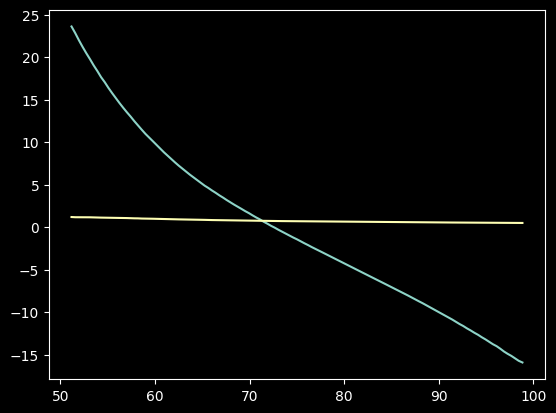

In [121]:
plt.plot(data.freqs, np.where(alan2['weight']>0, alan2['tsky'] - alan['tant'], np.nan))
plt.plot(data.freqs, np.where(alan2['weight']>0, alan2['tsky'] - alanbc['tant'], np.nan))

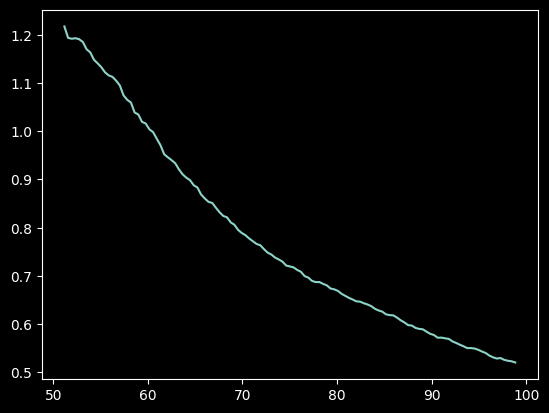

In [127]:
plt.plot(data.freqs, np.where(alan2['weight']>0, alan2['tsky'] - alanbc['tant'], np.nan))

In [110]:
sffit.success

True

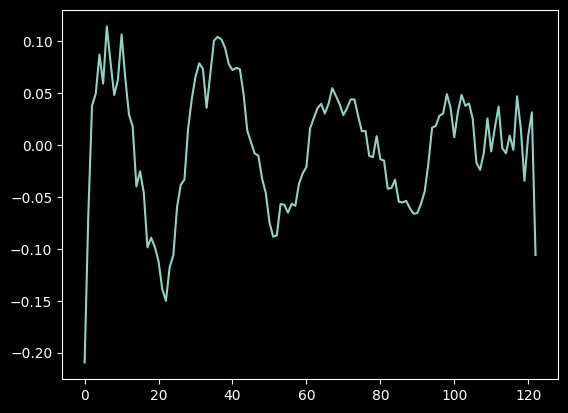

In [111]:
plt.plot(sf.get_eor(sffit.x) + sf.get_resid(sffit.x))

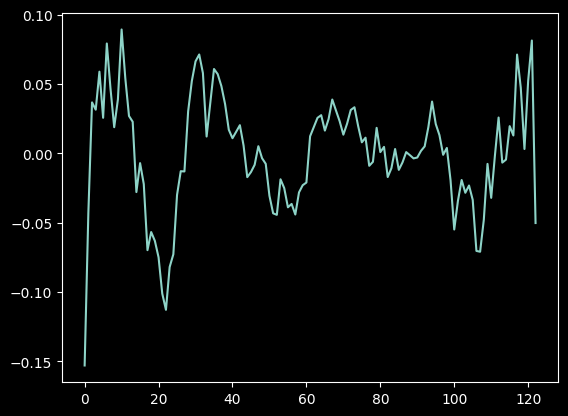

In [84]:
plt.plot(sf.get_resid(sffit.x))

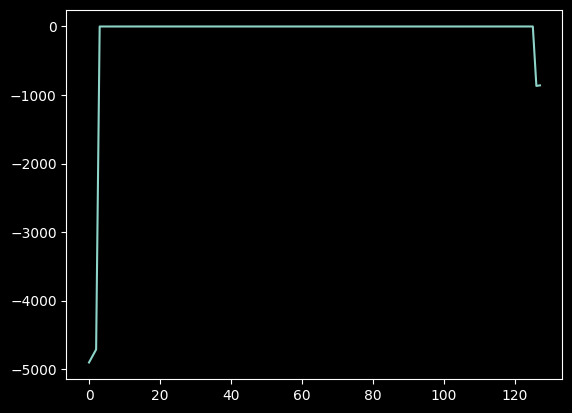

In [60]:
plt.plot(sf.get_resid({'amp': 0.5, 'tau': 7, 'w': 17.0, 'nu0': 78.0}))

In [14]:
sf.get_resid?

Signature: sf.get_resid(p)
Docstring: <no docstring>
File:      /data4/smurray/edges/edges-estimate/src/edges_estimate/fitting.py
Type:      method

In [ ]:
plt.plot(data.freqs, sf.get_resid